In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)
from sklearn.preprocessing import RobustScaler
import pathlib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

core_path    = os.getcwd()
results_path = os.path.join(core_path, 'data/results')
plots_path   = os.path.join(core_path, 'plots')
os.makedirs(results_path, exist_ok=True)
os.makedirs(plots_path,   exist_ok=True)

In [2]:
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl3/orbital_df.pkl'))

print(f"Total asteroids  : {len(orbital_df):,}")
print(f"Family members   : {orbital_df['is_family_member'].sum():,}")
print(f"Background       : {(~orbital_df['is_family_member']).sum():,}")
print(f"Class balance    : {orbital_df['is_family_member'].mean()*100:.1f}% family")

Total asteroids  : 1,038,241
Family members   : 230,607
Background       : 807,634
Class balance    : 22.2% family


In [3]:
FEATURES_A = ['a_p', 'e_p', 'sin_i_p', 'g', 's']

FEATURES_B = ['a_p', 'e_p', 'sin_i_p', 'g', 's',
              'rms_a', 'rms_e', 'rms_sin_i', 'LCE']

# Binary target — 1 = family member, 0 = background
y = orbital_df['is_family_member'].astype(int).values

print(f"Feature Set A : {FEATURES_A}")
print(f"Feature Set B : {FEATURES_B}")
print(f"Target classes: {np.unique(y, return_counts=True)}")

Feature Set A : ['a_p', 'e_p', 'sin_i_p', 'g', 's']
Feature Set B : ['a_p', 'e_p', 'sin_i_p', 'g', 's', 'rms_a', 'rms_e', 'rms_sin_i', 'LCE']
Target classes: (array([0, 1]), array([807634, 230607]))


In [4]:
results_summary = {}   # store all results here for final comparison

for feat_name, features in [('Set_A_orbital', FEATURES_A),
                             ('Set_B_full',    FEATURES_B)]:

    print(f"\n{'='*55}")
    print(f"Feature {feat_name}: {features}")
    print(f"{'='*55}")

    X = orbital_df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler  = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
    print(f"Train class balance: {y_train.mean()*100:.1f}% family")

    # ----- Random Forest -----
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    print("\nTraining Random Forest...")
    rf.fit(X_train, y_train)

    y_pred  = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    print(f"\n=== RF Binary — {feat_name} ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    results_summary[feat_name] = {
        'model': rf, 'scaler': scaler,
        'X_test': X_test, 'y_test': y_test,
        'y_pred': y_pred, 'y_proba': y_proba,
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc,
        'features': features
    }


Feature Set_A_orbital: ['a_p', 'e_p', 'sin_i_p', 'g', 's']
Train : 830,592  |  Test : 207,649
Train class balance: 22.2% family

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   44.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  6.6min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    2.3s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    3.8s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.5s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    2.5s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    4.4s finished



=== RF Binary — Set_A_orbital ===
Accuracy  : 0.9712
Precision : 0.9078
Recall    : 0.9686
F1        : 0.9372
ROC-AUC   : 0.9960

Feature Set_B_full: ['a_p', 'e_p', 'sin_i_p', 'g', 's', 'rms_a', 'rms_e', 'rms_sin_i', 'LCE']
Train : 830,592  |  Test : 207,649
Train class balance: 22.2% family

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   56.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  7.9min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    2.3s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    4.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    2.7s



=== RF Binary — Set_B_full ===
Accuracy  : 0.9659
Precision : 0.8965
Recall    : 0.9572
F1        : 0.9259
ROC-AUC   : 0.9944


[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    4.4s finished


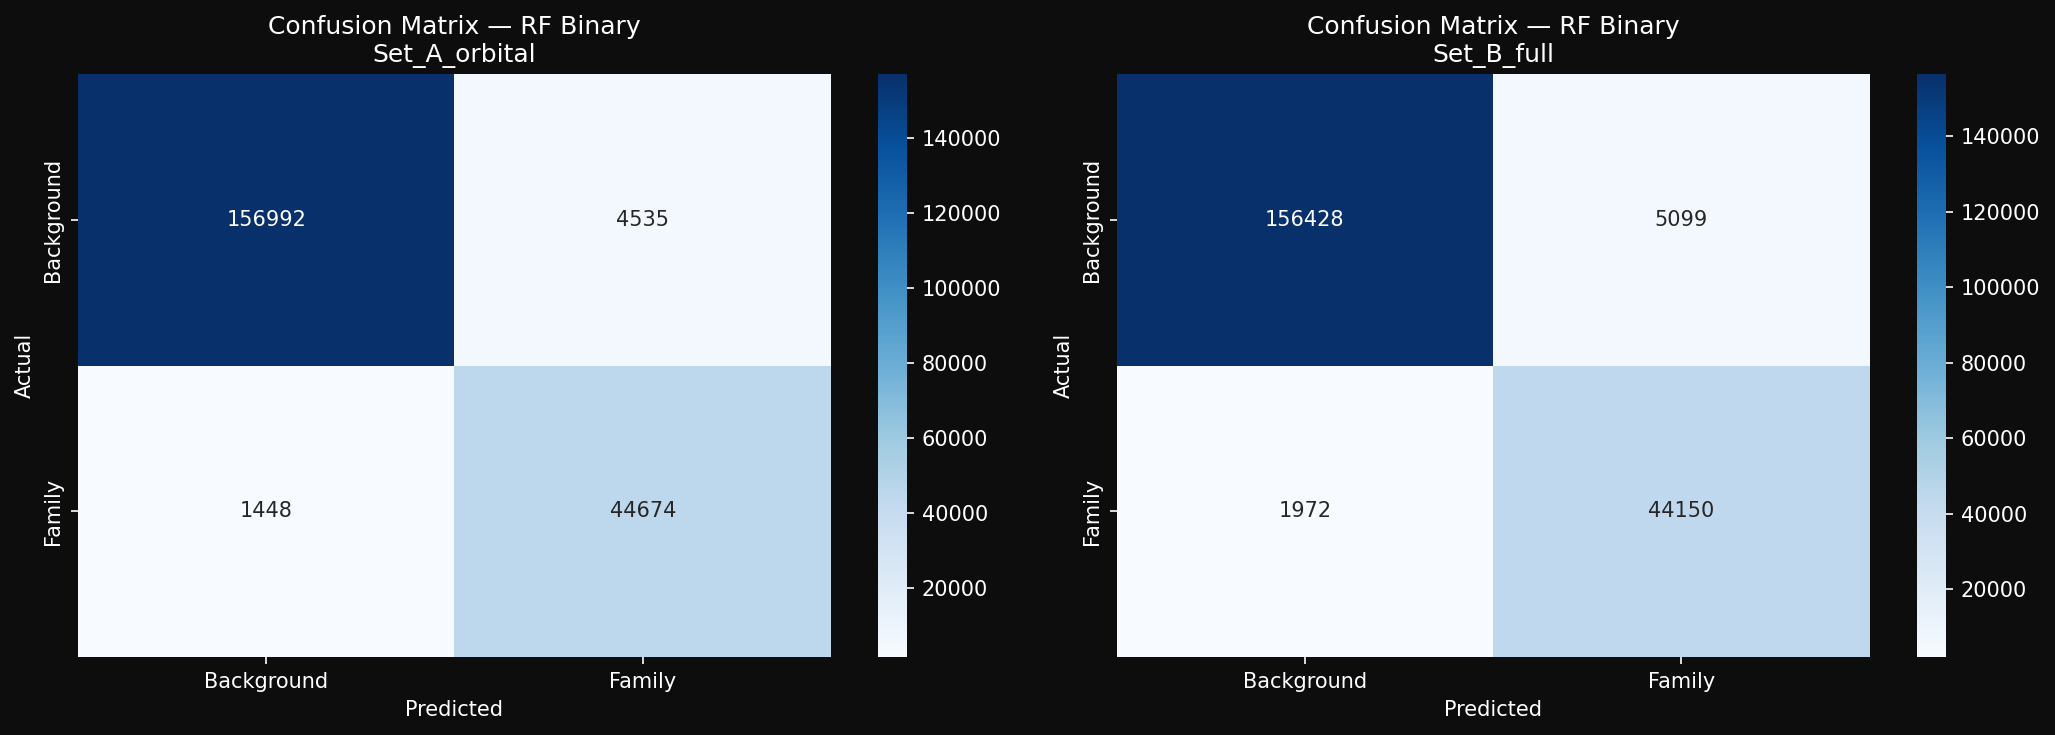

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (feat_name, res) in zip(axes, results_summary.items()):
    cm = confusion_matrix(res['y_test'], res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Background', 'Family'],
                yticklabels=['Background', 'Family'],
                ax=ax, cbar=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — RF Binary\n{feat_name}')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05a_i_rf_confusion.png'), dpi=200, bbox_inches='tight')
plt.show()

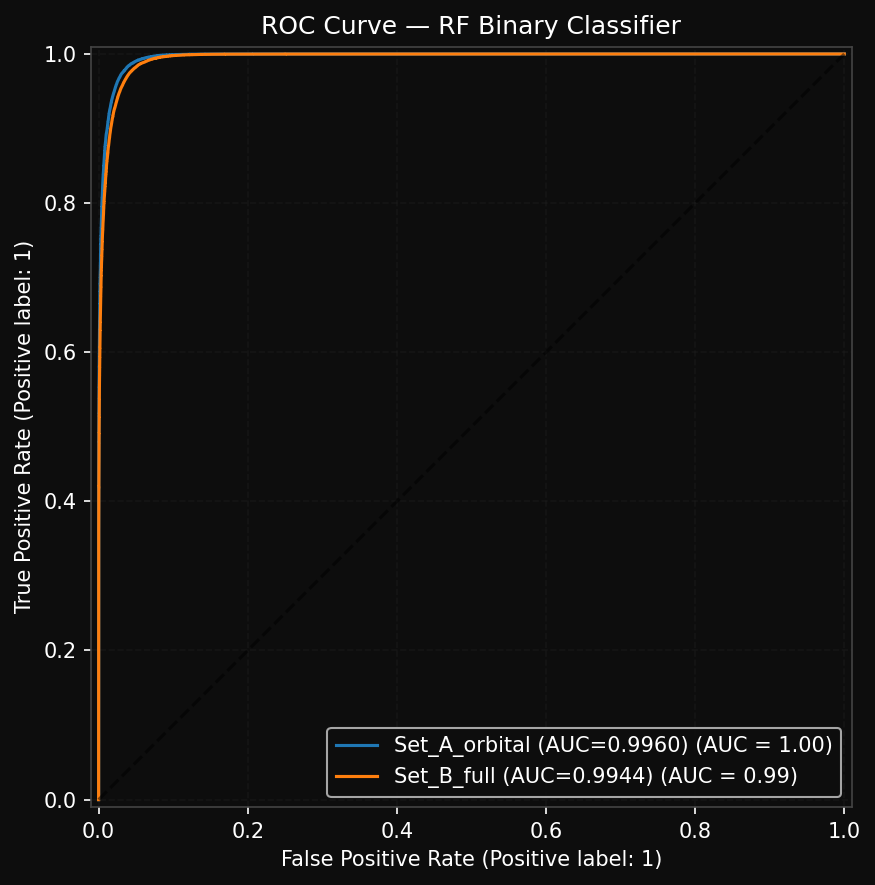

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

for feat_name, res in results_summary.items():
    RocCurveDisplay.from_predictions(
        res['y_test'], res['y_proba'],
        name=f"{feat_name} (AUC={res['auc']:.4f})",
        ax=ax
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_title('ROC Curve — RF Binary Classifier')
ax.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05a_i_rf_roc.png'), dpi=200, bbox_inches='tight')
plt.show()

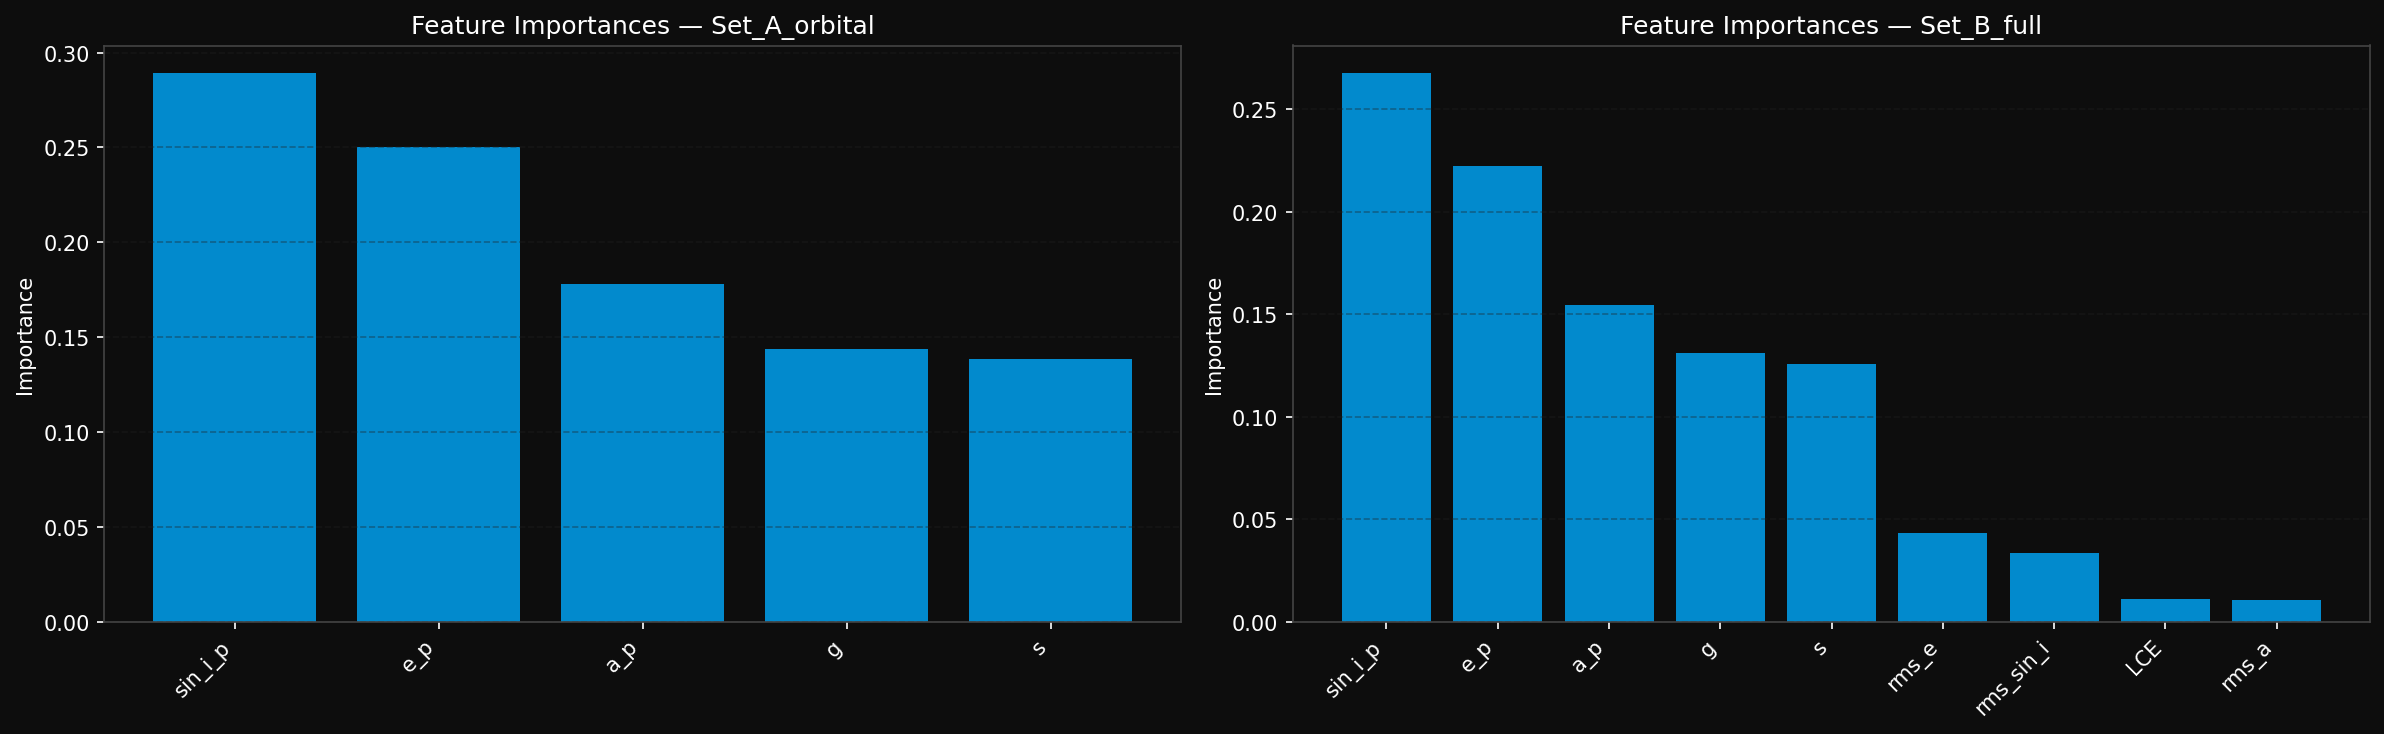

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (feat_name, res) in zip(axes, results_summary.items()):
    importances = res['model'].feature_importances_
    features    = res['features']
    sorted_idx  = np.argsort(importances)[::-1]

    ax.bar(range(len(features)),
           importances[sorted_idx],
           color='#00aaff', edgecolor='none', alpha=0.8)
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([features[i] for i in sorted_idx], rotation=45, ha='right')
    ax.set_ylabel('Importance')
    ax.set_title(f'Feature Importances — {feat_name}')
    ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05a_i_rf_importances.png'), dpi=200, bbox_inches='tight')
plt.show()

In [8]:
print(f"\n{'='*65}")
print(f"{'RF Binary Classification — Summary':^65}")
print(f"{'='*65}")
print(f"{'Feature Set':<20} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print(f"{'-'*65}")
for feat_name, res in results_summary.items():
    print(f"{feat_name:<20} {res['acc']:>8.4f} {res['prec']:>8.4f} "
          f"{res['rec']:>8.4f} {res['f1']:>8.4f} {res['auc']:>8.4f}")


               RF Binary Classification — Summary                
Feature Set               Acc     Prec      Rec       F1      AUC
-----------------------------------------------------------------
Set_A_orbital          0.9712   0.9078   0.9686   0.9372   0.9960
Set_B_full             0.9659   0.8965   0.9572   0.9259   0.9944


In [9]:
import os
import pickle

# Create classification_results directory
results_path = os.path.join('data', 'results', 'classification_results')
os.makedirs(results_path, exist_ok=True)

# Prepare save dictionary
save_dict = {
    feat_name: {
        'y_test':  res['y_test'],
        'y_pred':  res['y_pred'],
        'y_proba': res['y_proba'],
        'acc': res['acc'],
        'prec': res['prec'],
        'rec': res['rec'],
        'f1': res['f1'],
        'auc': res['auc'],
        'features': res['features'],
        'importances': res['model'].feature_importances_
    }
    for feat_name, res in results_summary.items()
}

# Save pickle file
save_file = os.path.join(
    results_path,
    '06a_i_binary_rf_results.pkl'
)

with open(save_file, 'wb') as f:
    pickle.dump(save_dict, f)

print(f"Saved → {save_file}")

Saved → data/results/classification_results/06a_i_binary_rf_results.pkl
